Dataset que muestra el comportamiento de los estudiantes frente a las nuevas herramientas IA. En este archivo se encuentras variables tanto de indole academica, institucional, encuestas, etc. Siendo una muestra de datos bastante completa y con varios posibles enfoques de investigacion.

La matriz de datos cuenta con 50000 entradas con 16 columnas detalladas a continuacion:

* Major_Category: campo de estudio a la que pertenece el estudiante
* Year_of_Study: situacion academica
* Pre_Semester_GPA: notas al inicio del semestre
* Weekly_GenAI_Hours: Horas semanales de uso de Ia
* Primary_Use_case: Tipo de uso
* Promp_Engineering_skill: Nivel de conocimiento de creacion de instruccion IA
* Tool_diversity: Cantidad de Ia's usadas
* Paid_Subscripcion: si se posee suscripcion
* Traditional_study_hours: horas de estudio sin ia
* Perceived_AI_Dependency: Dependencia percivida a la IA (1-5)
* Institutional_Policy: politica de la institucion de estudio frente a IA
* Anxiety_level_duting_exams: nivel de ansiedad durante epoca de examen
* Post_semestre_GPA: notas al fin del semestre
* Skill_retention_score: Puntaje de retencion de materias (1-10)
* Burnout_risk_level: nivel de riesgo de subrir alto stress

Fuente: https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data

## Sección 0 — Configuración inicial

In [ ]:
# ============================================================
#   PARÁMETROS
# ============================================================
FILEPATH     = 'dataset1_ai_student_impact.csv'
TARGET       = 'Paid_Subscription'
TEST_SIZE    = 0.2
RANDOM_STATE = 42


In [ ]:
# ============================================================
#   IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.pipeline         import make_pipeline
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, classification_report,
                                       ConfusionMatrixDisplay, roc_curve)
from scipy.stats              import randint, uniform

print('✅ Imports OK')

✅ Imports OK


In [ ]:
# ============================================================
#   CARGA DE DATOS
# ============================================================
df = pd.read_csv(FILEPATH)
df = df.reset_index(drop=True)
df = df.drop(columns='Student_ID')

print(f'Shape: {df.shape}')
display(df.head())
print()
display(df.tail())

Shape: (50000, 15)


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


---
## Sección I — Exploración y Limpieza (EDA)

### I.1 — Información general

In [ ]:
print('================================= Info =================================')
df.info()
print()
print('================================= Describe =================================')
display(df.describe().T)
print('================================= Variables Categóricas =================================')
cat_cols = df.select_dtypes(include='object').columns
cat_stats = pd.DataFrame({
    'n_unique'  : df[cat_cols].nunique(),
    'moda'      : df[cat_cols].mode().iloc[0],
    'frec_moda' : df[cat_cols].apply(lambda x: x.value_counts().iloc[0]),
    'pct_moda'  : df[cat_cols].apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100).round(1),
})
display(cat_stats)

# Tipos de datos correctos
# columnas se ven con rangos esperable

================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  object 
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_G

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


================================= Variables Categóricas =================================


,n_unique,moda,frec_moda,pct_moda
Major_Category,5,STEM,15059,30.1
Year_of_Study,5,Junior,11045,22.1
Primary_Use_Case,5,Debugging/Troubleshooting,12295,24.6
Prompt_Engineering_Skill,3,Beginner,18495,37.0
Institutional_Policy,3,Allowed_With_Citation,25224,50.4
Burnout_Risk_Level,3,Medium,21144,42.3


### I.2 — Duplicados

In [ ]:
n_dup = df.duplicated().sum()
print(f'Filas iniciales : {len(df)}')
print(f'Duplicados      : {n_dup} ({n_dup/len(df)*100:.2f}%)')

if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Filas tras limpieza: {len(df)}')
else:
    print('Sin duplicados ✓')

Filas iniciales : 50000
Duplicados      : 0 (0.00%)
Sin duplicados ✓


### I.3 — Nulos

In [ ]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje': pct}).query('nulos > 0')
display(nulos_df if not nulos_df.empty else pd.DataFrame({'resultado': ['Sin nulos ✓']}))



,resultado
0,Sin nulos ✓


### I.4 — Inconsistencias categóricas

In [ ]:
# no hay problemas con las columnas categoricas

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('================================= Value Counts =================================\n')
for col in cat_cols:
    print(f'===== {col} =====')
    display(df[col].value_counts())
    print()

print('================================= Verificación de capitalización =================================\n')
for col in cat_cols:
    original = df[col].nunique()
    lower    = df[col].str.lower().nunique()
    if original != lower:
        print(f"  ⚠️  INCONSISTENCIA en '{col}': {original} vs {lower}")
        df[col] = df[col].str.strip().str.lower()
    else:
        print(f"  '{col}': sin inconsistencias ✓")

================================= Value Counts =================================

===== Major_Category =====


,count
Major_Category,
STEM,15059
Business,12538
Humanities,9994
Medical,6476
Arts,5933



===== Year_of_Study =====


,count
Year_of_Study,
Junior,11045
Freshman,11031
Senior,10634
Sophomore,9860
Graduate,7430



===== Primary_Use_Case =====


...


===== Institutional_Policy =====


,count
Institutional_Policy,
Allowed_With_Citation,25224
Actively_Encouraged,14988
Strict_Ban,9788



===== Burnout_Risk_Level =====


,count
Burnout_Risk_Level,
Medium,21144
Low,16369
High,12487



================================= Verificación de capitalización =================================

  'Major_Category': sin inconsistencias ✓
  'Year_of_Study': sin inconsistencias ✓
  'Primary_Use_Case': sin inconsistencias ✓
  'Prompt_Engineering_Skill': sin inconsistencias ✓
  'Institutional_Policy': sin inconsistencias ✓
  'Burnout_Risk_Level': sin inconsistencias ✓


### I.5 — Outliers (IQR)

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()

outlier_report = []
for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'columna': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                           'lim_inf': round(lower,2), 'lim_sup': round(upper,2),
                           'outliers': n_out, 'pct': round(n_out/len(df)*100,2)})
display(pd.DataFrame(outlier_report))


,columna,Q1,Q3,lim_inf,lim_sup,outliers,pct
0,Pre_Semester_GPA,2.83,3.52,1.80,4.55,328,0.66
1,Weekly_GenAI_Hours,2.39,11.72,-11.60,25.72,2583,5.17
2,Tool_Diversity,2.00,4.00,-1.00,7.00,0,0.00
3,Traditional_Study_Hours,7.56,14.71,-3.17,25.44,161,0.32
4,Perceived_AI_Dependency,2.00,5.00,-2.50,9.50,190,0.38
5,Anxiety_Level_During_Exams,3.00,6.00,-1.50,10.50,0,0.00
6,Post_Semester_GPA,3.02,3.75,1.94,4.84,346,0.69
7,Skill_Retention_Score,66.82,85.19,39.26,112.74,216,0.43


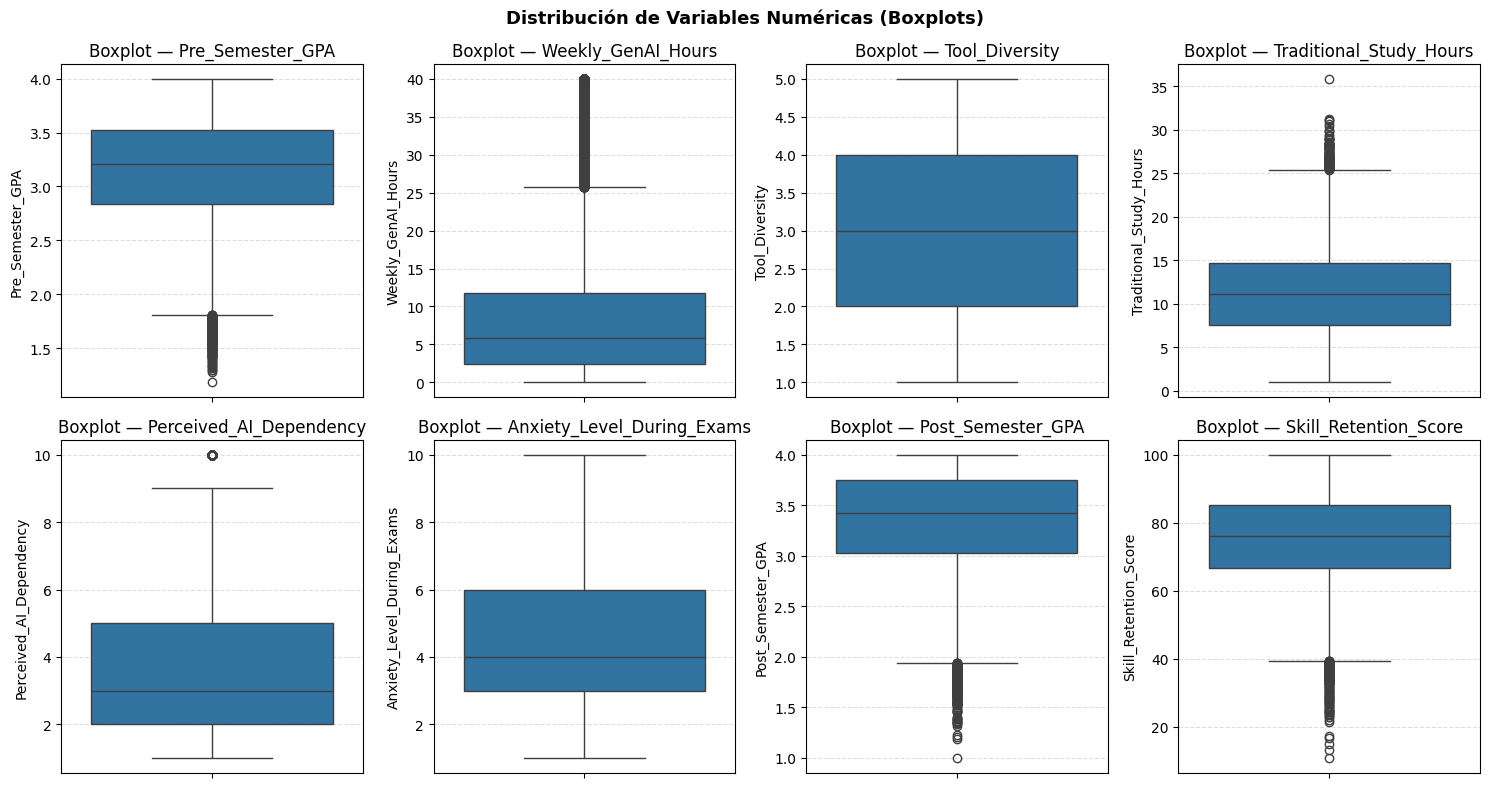

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8), dpi=100)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Boxplot — {col}')
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Numéricas (Boxplots)', fontsize=13, fontweight='bold')
print()
plt.tight_layout(); plt.show()

Existe una gran cantidad de outliers en varios graficos, analizando los rangos de cada uno se determina que son valores reales y esperables bajo ciertas circunstancias, asique se mantendran para tener informacion de esos casos menos comunes

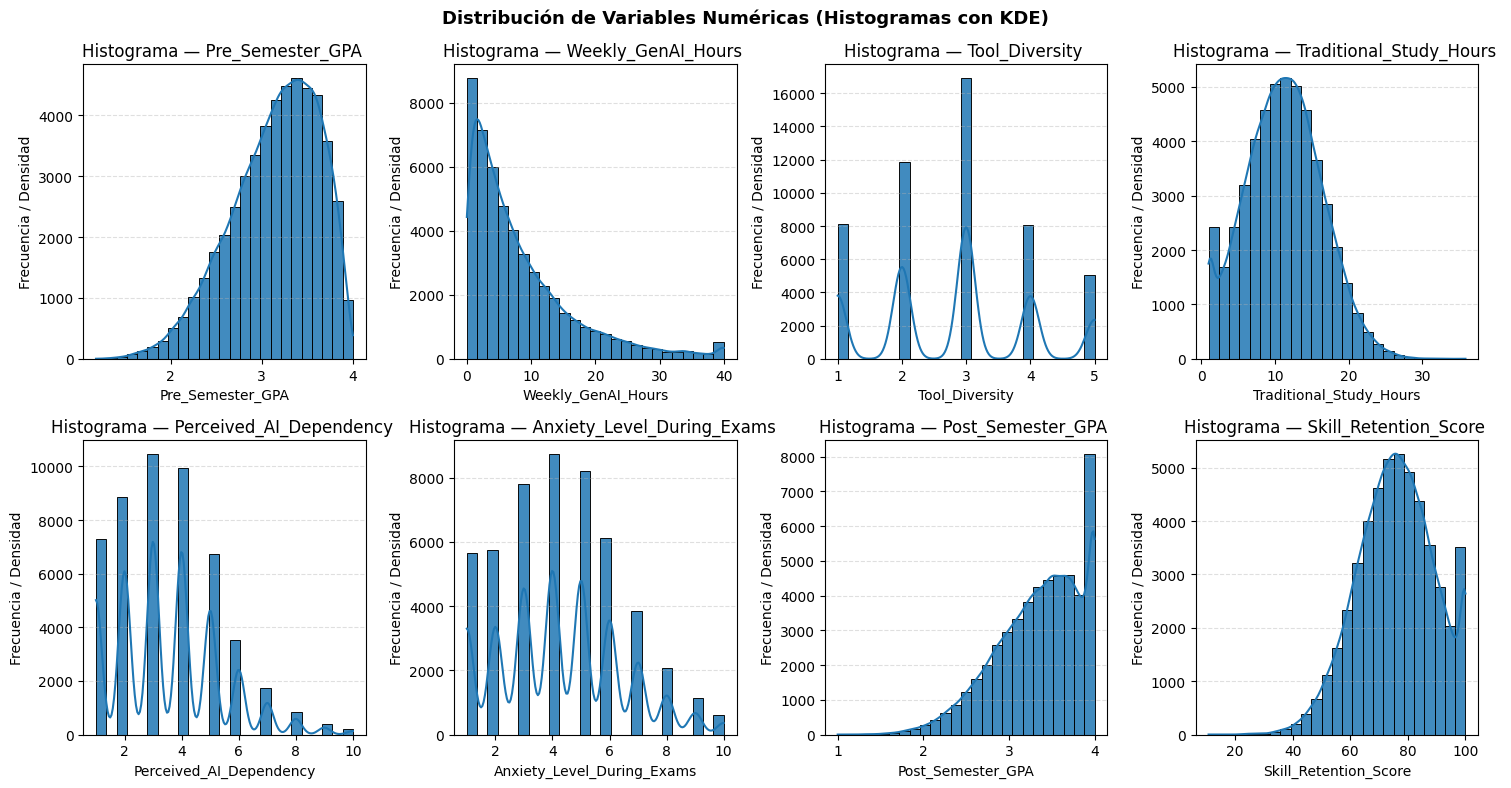

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8), dpi=100)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=25, ax=ax, kde=True, alpha=0.85)
    ax.set_title(f'Histograma — {col} ')
    ax.set_xlabel(col); ax.set_ylabel('Frecuencia / Densidad')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Numéricas (Histogramas con KDE)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



La distribucion de algunos graficos como `pre_semester_GPA` y  `traditional_study_hours` presentan una distribucion semejante a la normal, aptos para StandarScaler, por el contrario las demas variables deberan pasar por un MinMaxScaler, y las variables `Tool_diversity`, `Perceived_ai_dependancy` y `anxiety_lvl_during_exams` pueden perfectamente ser pasadas a variables categoricas ordinales.
Ambos graficos de GPA tienen una buena distribucion con enfoque en valores altos, mientras que la mayoria de estudiantes poseen una cantidad de horas de estudio y hroas de uso de IA con tendencias bajas.

### I.6 — Variable objetivo: Paid_Subscription

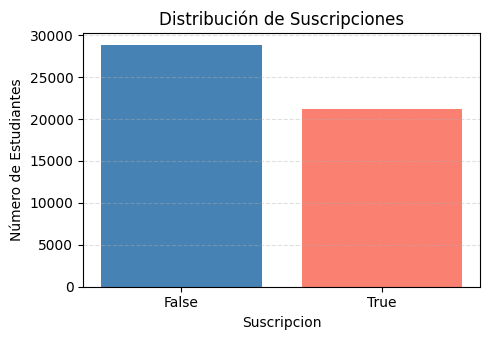

,count
Paid_Subscription,
False,28846
True,21154


In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=100)
counts = df['Paid_Subscription'].value_counts().sort_index()
ax.bar(counts.index.astype(str), # se combierte a str para poder graficoar
       counts.values,
       color=['steelblue', 'salmon'], edgecolor='none')

ax.set_title('Distribución de Suscripciones', fontsize=12)
ax.set_xlabel('Suscripcion')
ax.set_ylabel('Número de Estudiantes')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

display(counts)

Se aprecia un mayor numero de estudiantes que utilizan las versiones basicas de IA, sin desmerecer la cantidad de alumnos suscritos a una version premium. El dataset no se encuentra desbalanceado.

### I.6 — Heatmap correlación

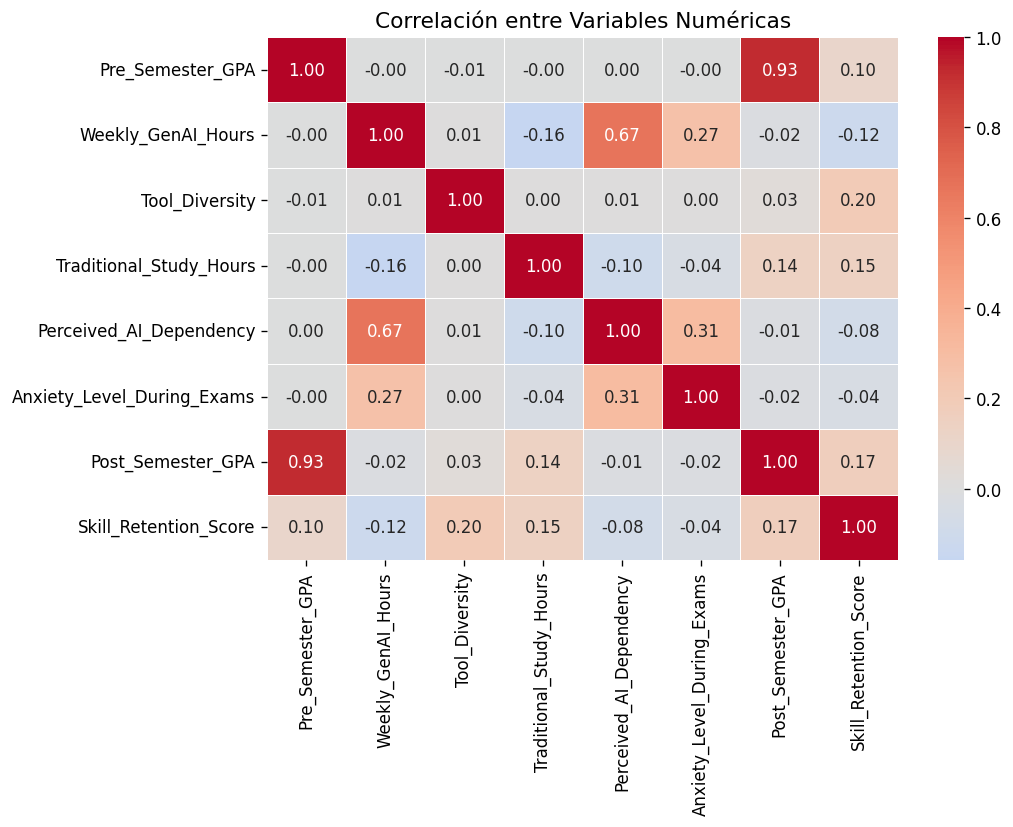

In [ ]:
# Heatmap de correlación numérica
num_for_corr = df.select_dtypes(include='number').columns.tolist()
plt.figure(figsize=(9, 7), dpi=120)
sns.heatmap(df[num_for_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlación entre Variables Numéricas', fontsize=13)
plt.tight_layout(); plt.show()

En general las correlaciones son bastante bajas, por destacar algunas se puede mencionar que la anciedad durante examenes se relaciona positivamente con las horas de uso de IA y con la dependencia a estas herramientras.
Las notas pre y post semestre tienen una alta correlacion que tiene sentido ya que no es normal que el alumno presente un cambio abrupto entre semestres, al final y al caso sigue siendo la misma persona.
Igualmente la cantidad de horas que se usan los generados Ia tiene alta correlacion con dependencia percibida, dando a notar que la gente se da cuenta de sus necesidad a esta nueva tecnologia.

---
## Sección II — Resumen y hallazgos

In [ ]:
print('=' * 65)
print('  INFORME FINAL ')
print('=' * 65)

print(f'''
Dataset:
Filas         : {len(df)}
Features      : {df.columns}
Target        : Paid_suscripcion
Nulos                : 0 encontrados
Outliers             : Mantenidos (valores reales)
''')

print('''Hallazgos:
* Mayoria de estudiantes no posee suscripcion de pago a un agente de Ia
* La mayoria de estudiantes tiende a tener bajas horas de estudio tradicional y 8 horas de media de uso de IA para el estudio
* La mayoria de estudiantes usa mas de una IA para sus trabajos, posiblemente ya que usan la version gratuita deben cambiar de herramienta al cumplir la cuota
* La percepcion general es que no se sienten muy dependientes de la Ia para sus obligaciones
''')

print('''Desafios:
* El dataset es bastante completo, tanto que se tomo una muestra aleatorio para poder hacer este eda, por lo que se deberia disponer de altas capacidades de procesamiento para un analisis completo
* Se pueden realizar multiples enfoques en el trabajo desde una postura de venta usando paid_suscripcion, social con ia_dependancy o psicologica con el anxiety_level
* Las variables numericas no tienen altas correlaciones entre ellas, porque se deberia explorar la opcion de convertir algunas a categorias ordinales con el fin de analizar su impacto en un modelo de prediccion
''')

print('')
print('=' * 65)

  INFORME FINAL 

Dataset:
Filas         : 50000
Features      : Index(['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')
Target        : Paid_suscripcion
Nulos                : 0 encontrados
Outliers             : Mantenidos (valores reales)

Resumen modelos:


NameError: name 'opt_df' is not defined

Resumir los principales hallazgos de cada EDA, destacando las características y desafíos únicos de cada conjunto de datos